# Thomson GP サンプル

`tsmap_calib` の電子温度・密度を GP で再構成し、マップ、プロファイル、時間発展、空間・時間微分を表示します。データ取得と最適化に時間がかかるため、既定では実行しません。

In [1]:
import matplotlib.pyplot as plt

from mylhd import KaisekiData, ThomsonGP

## 1. 対象ショットと実行条件を設定する

In [ ]:
SHOTNO = 194042
RUN_GP = False
TIME_SCALE = 0.2
REFF_SCALE = 0.5

## 2. 元データを確認する

まず `KaisekiData` だけで接続と値名を確認します。

In [3]:
if RUN_GP:
    source = KaisekiData.retrieve_opendata(diag="tsmap_calib", shotno=SHOTNO, subno=1)
    source.show()
else:
    print("GP execution is disabled. Set RUN_GP=True after checking the target shot.")

#name: tsmap_calib  #shotno: 194042  #subno: 1  #date: 10/06/2025 17:03
Data Shape: (344, 140, 32)
dimnames:  'Time', 'R'
dimunits:  's'   , 'm'
valnames:  'reff', 'Te' , 'Te_bayesian', 'dTe', 'ne_calFIR', 'ne_bayesian', 'ne_symmetry', 'dne_calFIR', 'Te_fit', 'Te_fit_err', 'dTedr', 'dTedr_err', 'ne_fit', 'ne_fit_err', 'dnedr' , 'dnedr_err', 'Te_systematic_error', 'ne_systematic_error', 'cor_symmetry', 'reff/a99', 'reff/a999', 'Wpe', 'dVdreff', 'phi', 'beta_e', 'ne_original', 'dne', 'Br', 'Bz', 'Bphi'
valunits:  'm'   , 'keV', 'keV'        , 'keV', 'e19m-3'   , 'e19m-3'     , 'e19m-3'     , 'e19m-3'    , 'keV'   , 'keV'       , 'keV/m', 'keV/m'    , 'e19m-3', 'e19m-3'    , 'e19m-4', 'e19m-4'   , 'arb'                , 'arb'                , 'arb'         , 'arb'     , 'arb'      , 'kJ' , 'm2'     , 'Wb' , '%'     , 'arb'        , 'arb', 'T' , 'T' , 'T'   


## 3. Te と ne を再構成する

In [4]:
thomson = None

if RUN_GP:
    thomson = ThomsonGP(shotNo=SHOTNO, iprint=True)
    thomson.pipeline_sigma_optimize(
        "Te",
        time_scale=TIME_SCALE,
        reff_scale=REFF_SCALE,
        omega=0.01,
        iprint=True,
    )
    thomson.pipeline_sigma_optimize(
        "ne",
        time_scale=TIME_SCALE,
        reff_scale=REFF_SCALE,
        omega=0.02,
        iprint=True,
    )
    profile_time = float(thomson.time_inp[len(thomson.time_inp) // 2])
    trace_reff = 0.4
    print(f"Plot time: {profile_time:.4f} s, trace reff: {trace_reff:.2f}")

original data shape is (344, 140)
effective data shape is (212, 140)
out_scale_Te: 1.704 out_scale_Ne: 1.155
KernelType is set to be Matern 5/2
initial sigmaTe scale: 1 optimized sigma scale: 0.9449576896245038 cuttoff: 1e-5
optimized sigma scale: 0.9381566204860489
Te time: 1.2317206859588623
final optimized sigma scale: 0.9474247950305286
initial sigmane scale: 1 optimized sigma scale: 0.751026511786059 cuttoff: 1e-5
optimized sigma scale: 0.6985324045996935
optimized sigma scale: 0.6867621928803566
optimized sigma scale: 0.6840791287016594
Ne time: 1.1785647869110107
final optimized sigma scale: 0.6715507045709354
Plot time: 5.2504 s, trace reff: 0.40


## 4. Te・ne の時空間マップ

左から元データ、GP 再構成、空間微分、時間微分が表示されます。

(140,)
(140,)


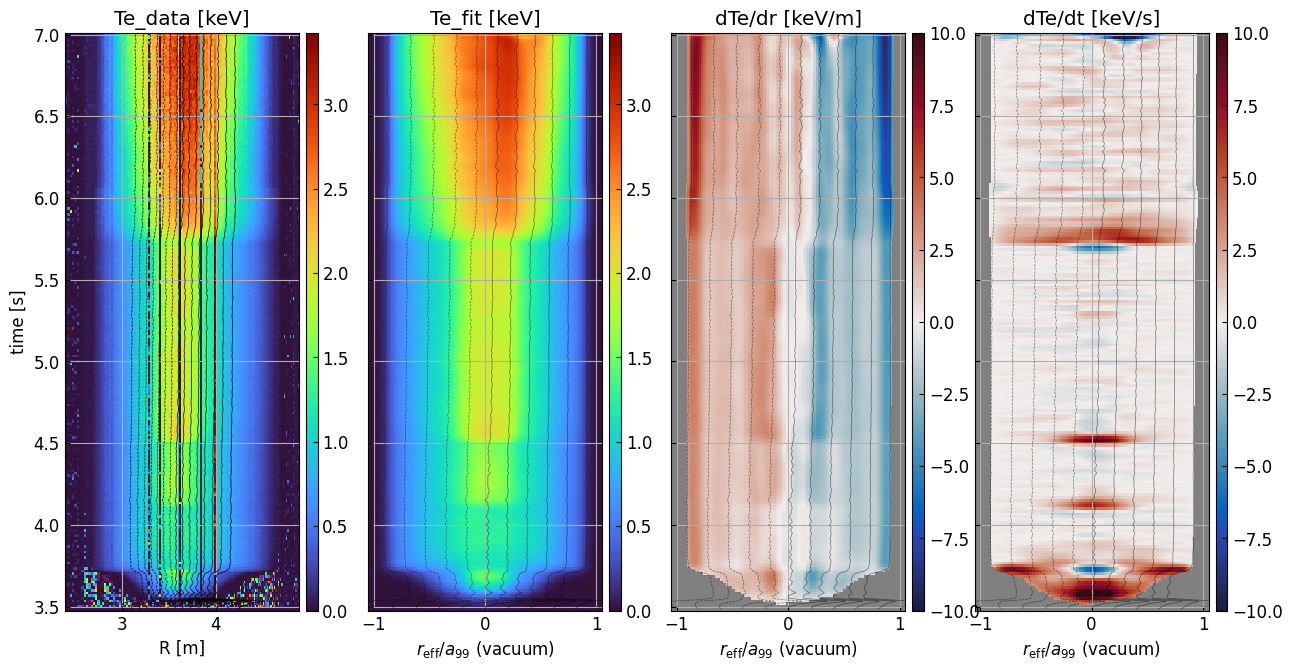

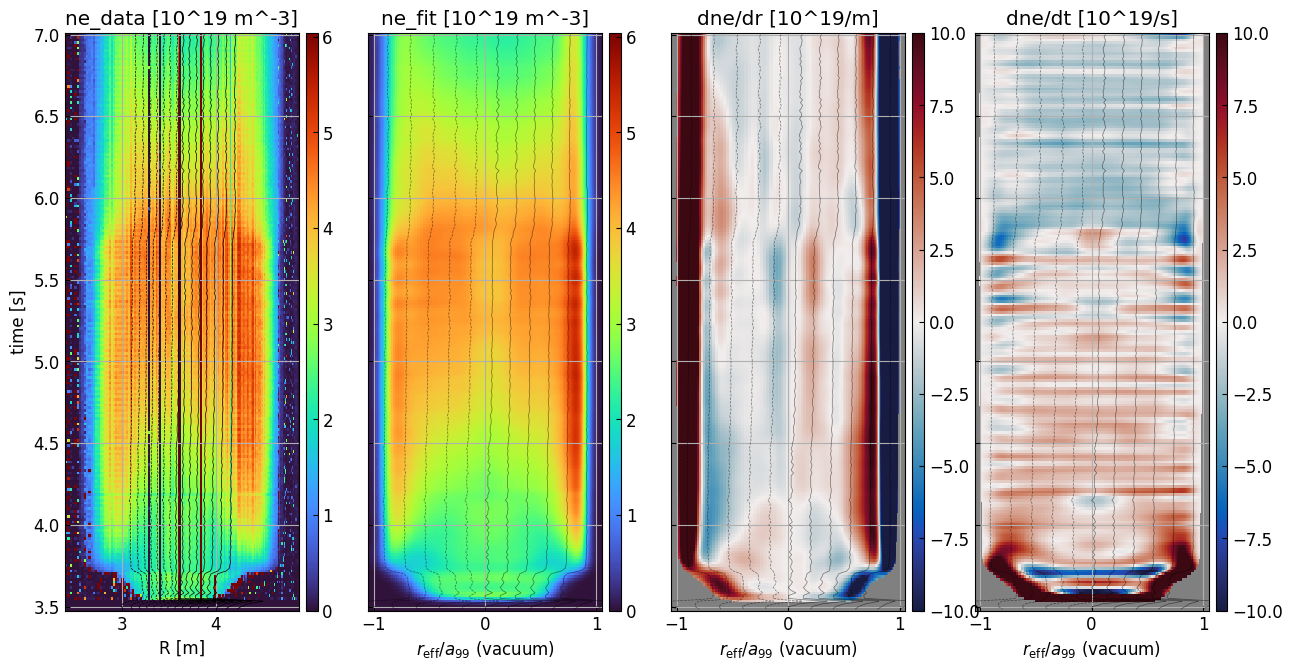

In [5]:
if thomson is not None:
    thomson.plot_im(ValName="Te", x_axis="rho_vac")
    thomson.plot_im(ValName="ne", x_axis="rho_vac")

## 5. 指定時刻の径方向プロファイル

観測点、除外点、GP 平均、事後分散を同時に確認します。

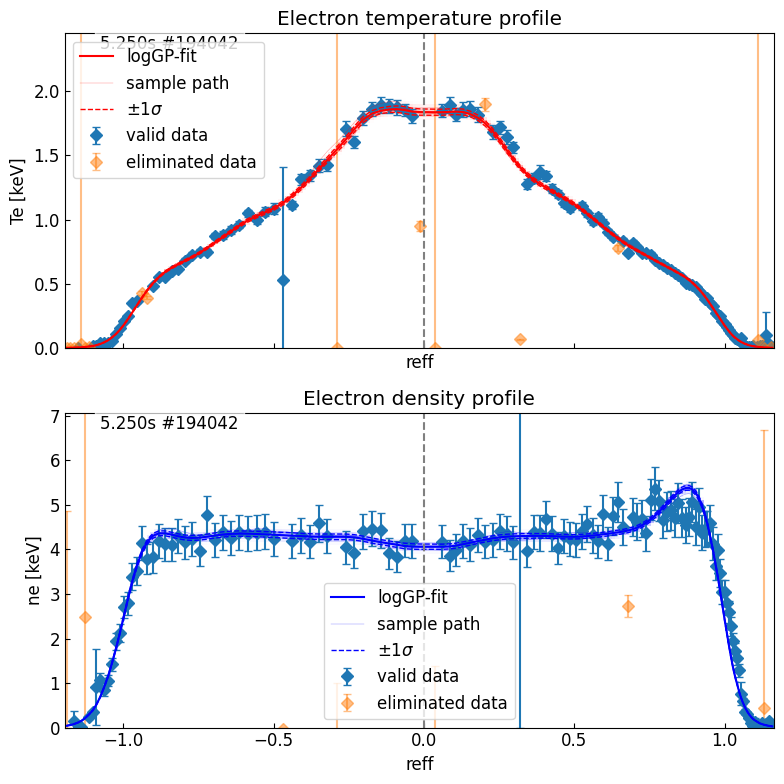

In [6]:
if thomson is not None:
    fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
    thomson.plotProfile("Te", time=profile_time, ax=axes[0], sampling=3)
    thomson.plotProfile("ne", time=profile_time, ax=axes[1], color="blue", sampling=3)
    axes[0].set_title("Electron temperature profile")
    axes[1].set_title("Electron density profile")
    fig.tight_layout()

## 6. 指定半径の時間発展

`reff` に最も近い観測位置で Te・ne の trace を表示します。

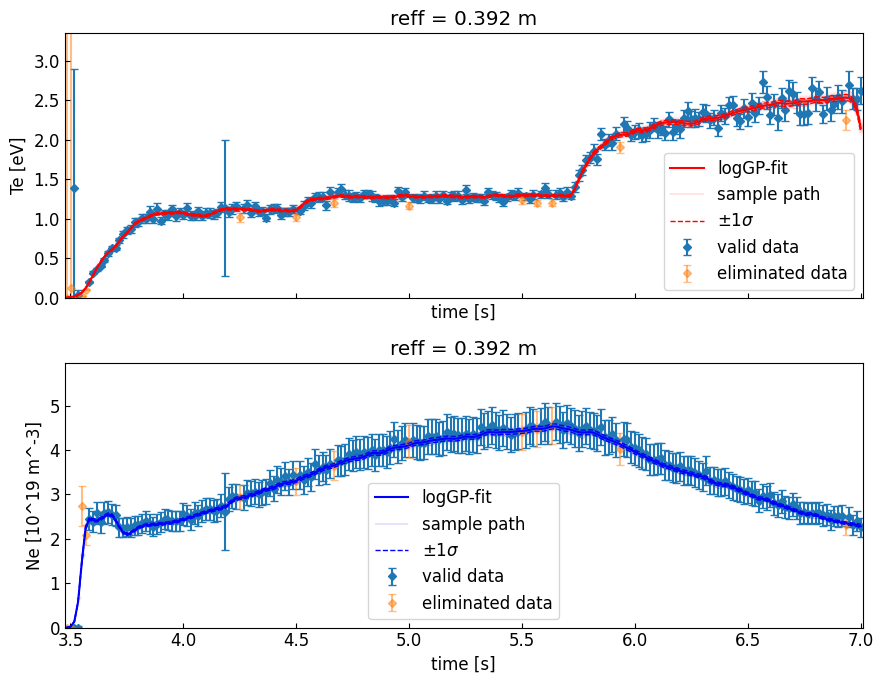

In [7]:
if thomson is not None:
    fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
    thomson.plotTrace("Te", reff=trace_reff, ax=axes[0], sampling=3)
    thomson.plotTrace("ne", reff=trace_reff, ax=axes[1], color="blue", sampling=3)
    fig.tight_layout()

## 7. 指定時刻における空間微分・時間微分

`DimName="reff"` は規格化半径方向、`DimName="time"` は時間方向の対数微分です。

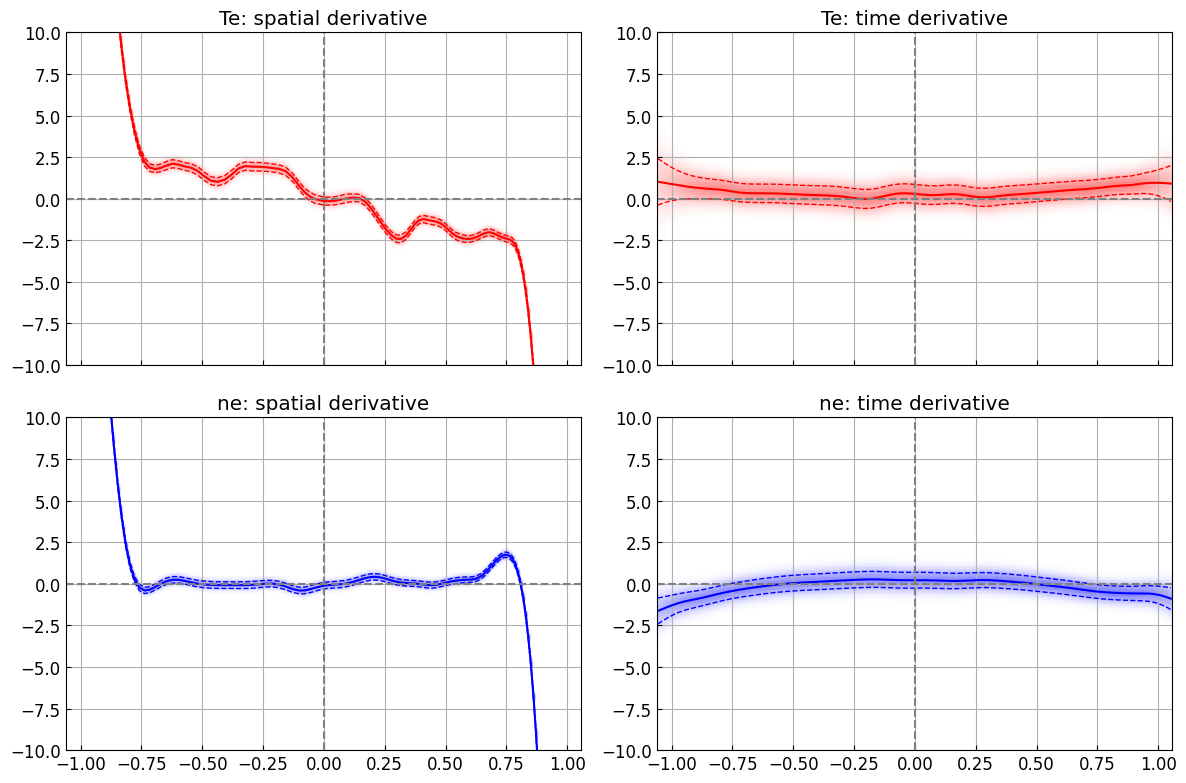

In [8]:
if thomson is not None:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    thomson.plotProfileDx("Te", DimName="reff", time=profile_time, ax=axes[0, 0])
    thomson.plotProfileDx("Te", DimName="time", time=profile_time, ax=axes[0, 1])
    thomson.plotProfileDx("ne", DimName="reff", time=profile_time, ax=axes[1, 0], color="blue")
    thomson.plotProfileDx("ne", DimName="time", time=profile_time, ax=axes[1, 1], color="blue")
    axes[0, 0].set_title("Te: spatial derivative")
    axes[0, 1].set_title("Te: time derivative")
    axes[1, 0].set_title("ne: spatial derivative")
    axes[1, 1].set_title("ne: time derivative")
    fig.tight_layout()

## 8. 指定半径における微分量の時間発展

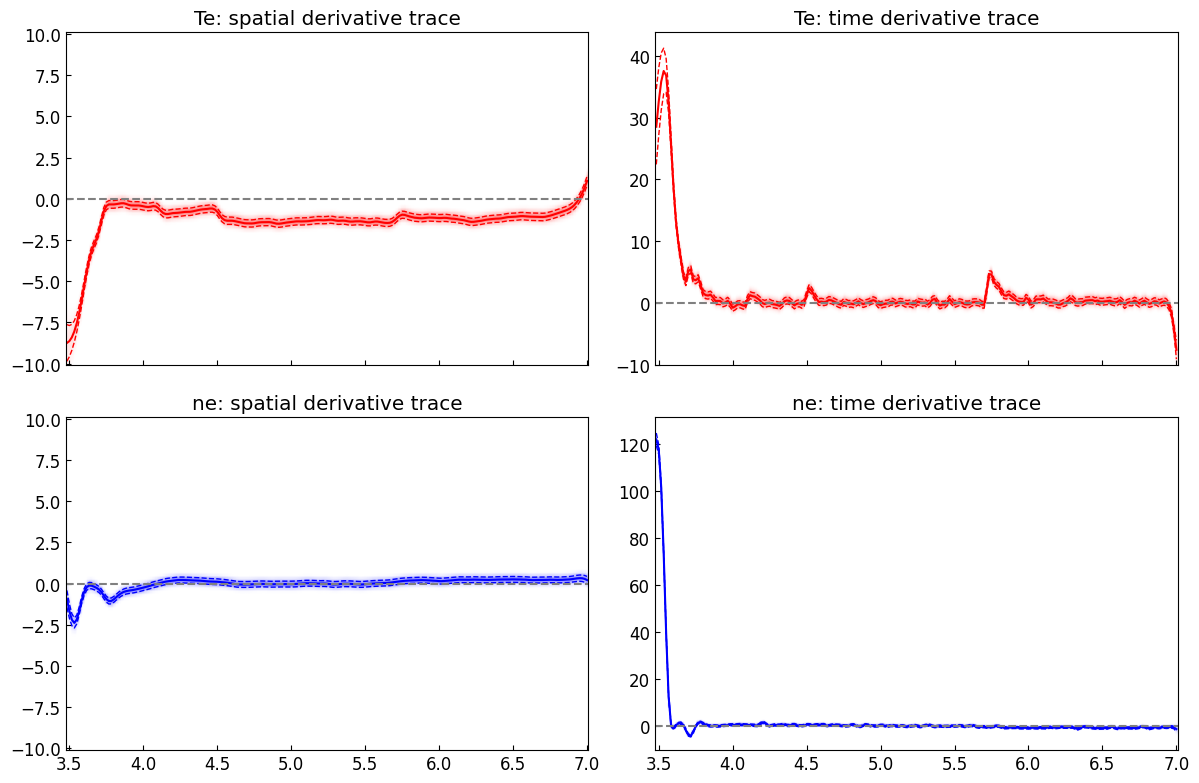

In [9]:
if thomson is not None:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    thomson.plotEvolutionDx("Te", DimName="reff", reff=trace_reff, ax=axes[0, 0])
    thomson.plotEvolutionDx("Te", DimName="time", reff=trace_reff, ax=axes[0, 1])
    thomson.plotEvolutionDx("ne", DimName="reff", reff=trace_reff, ax=axes[1, 0], color="blue")
    thomson.plotEvolutionDx("ne", DimName="time", reff=trace_reff, ax=axes[1, 1], color="blue")
    axes[0, 0].set_title("Te: spatial derivative trace")
    axes[0, 1].set_title("Te: time derivative trace")
    axes[1, 0].set_title("ne: spatial derivative trace")
    axes[1, 1].set_title("ne: time derivative trace")
    fig.tight_layout()

## 9. 最適化パラメータを保存する（任意）

保存先ディレクトリを用意してから実行します。

In [10]:
SAVE_RESULT = False

if thomson is not None and SAVE_RESULT:
    thomson.save(
        path="results/",
        filename=f"shot_{SHOTNO}_gp",
        timestamp=False,
        save_fig=False,
    )